Machine Learning Part 1 

Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as mat
import seaborn as sns 

Data Extraction

In [2]:
df=pd.read_csv(r'L:\4th sem\Mission Scopus\traffic_accidents.csv')

In [3]:
df.head(3)

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12


Exploratory Data Analysis (EDA)

In [4]:
df.shape

(209306, 24)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209306 non-null  str    
 1   traffic_control_device         209306 non-null  str    
 2   weather_condition              209306 non-null  str    
 3   lighting_condition             209306 non-null  str    
 4   first_crash_type               209306 non-null  str    
 5   trafficway_type                209306 non-null  str    
 6   alignment                      209306 non-null  str    
 7   roadway_surface_cond           209306 non-null  str    
 8   road_defect                    209306 non-null  str    
 9   crash_type                     209306 non-null  str    
 10  intersection_related_i         209306 non-null  str    
 11  damage                         209306 non-null  str    
 12  prim_contributory_cause        209306 non

There is no any null value, here.

In [6]:
df.isnull().sum()

crash_date                       0
traffic_control_device           0
weather_condition                0
lighting_condition               0
first_crash_type                 0
trafficway_type                  0
alignment                        0
roadway_surface_cond             0
road_defect                      0
crash_type                       0
intersection_related_i           0
damage                           0
prim_contributory_cause          0
num_units                        0
most_severe_injury               0
injuries_total                   0
injuries_fatal                   0
injuries_incapacitating          0
injuries_non_incapacitating      0
injuries_reported_not_evident    0
injuries_no_indication           0
crash_hour                       0
crash_day_of_week                0
crash_month                      0
dtype: int64

In [7]:
df.columns

Index(['crash_date', 'traffic_control_device', 'weather_condition',
       'lighting_condition', 'first_crash_type', 'trafficway_type',
       'alignment', 'roadway_surface_cond', 'road_defect', 'crash_type',
       'intersection_related_i', 'damage', 'prim_contributory_cause',
       'num_units', 'most_severe_injury', 'injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour',
       'crash_day_of_week', 'crash_month'],
      dtype='str')

In [8]:
numeric_columns=['injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour',
       'crash_day_of_week', 'crash_month']
numeric_columns

['injuries_total',
 'injuries_fatal',
 'injuries_incapacitating',
 'injuries_non_incapacitating',
 'injuries_reported_not_evident',
 'injuries_no_indication',
 'crash_hour',
 'crash_day_of_week',
 'crash_month']

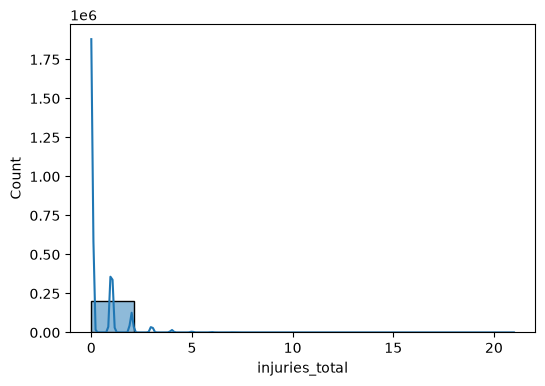

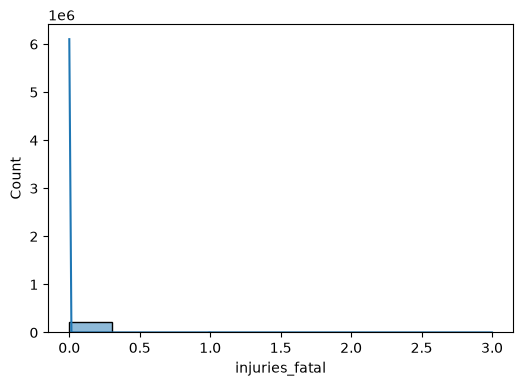

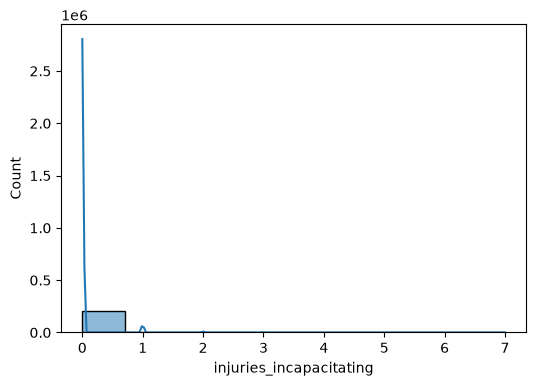

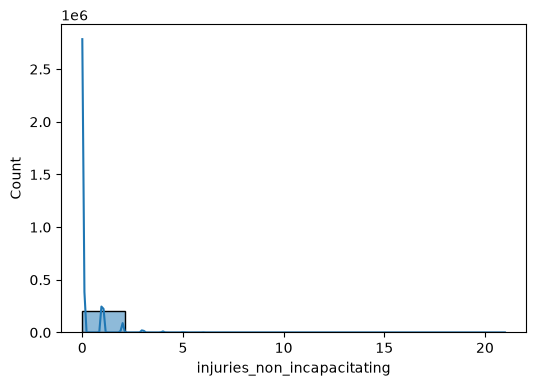

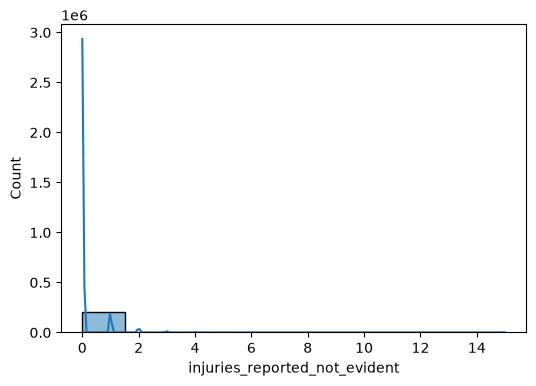

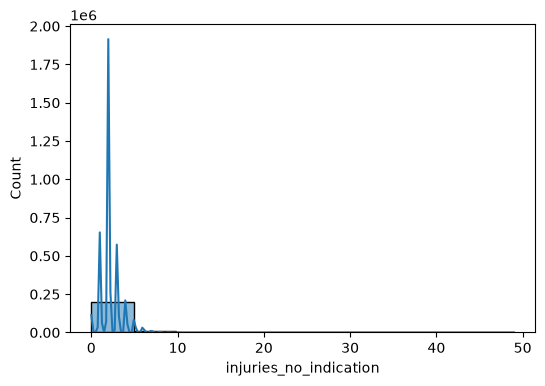

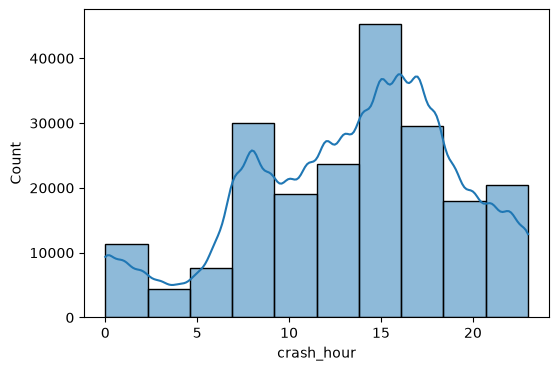

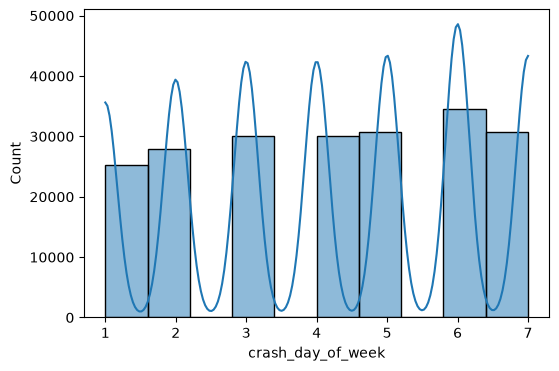

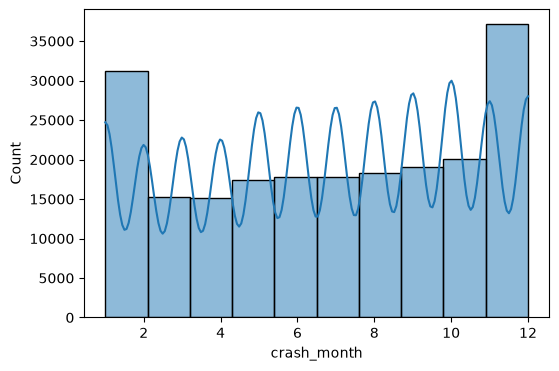

In [9]:
for col in numeric_columns:
    mat.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=10)

<Axes: xlabel='injuries_fatal', ylabel='count'>

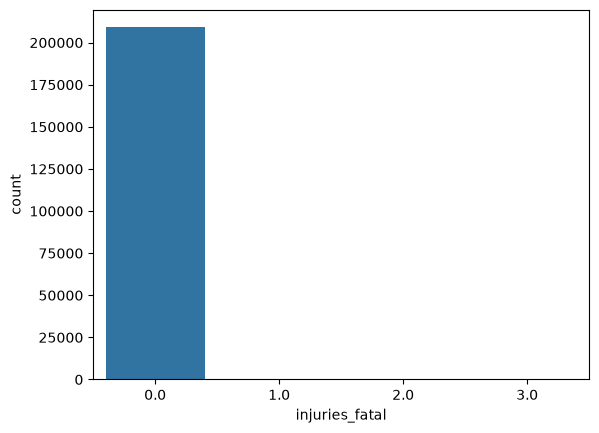

In [10]:
sns.countplot(x=df["injuries_fatal"])

<Axes: xlabel='count', ylabel='weather_condition'>

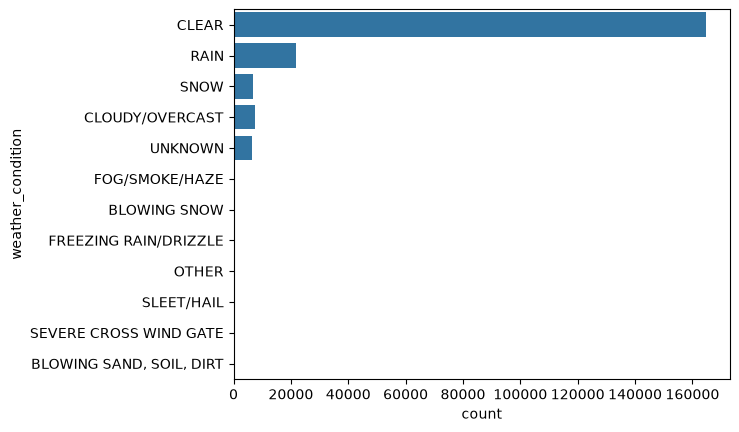

In [11]:
sns.countplot(y=df["weather_condition"])

<Axes: xlabel='count', ylabel='traffic_control_device'>

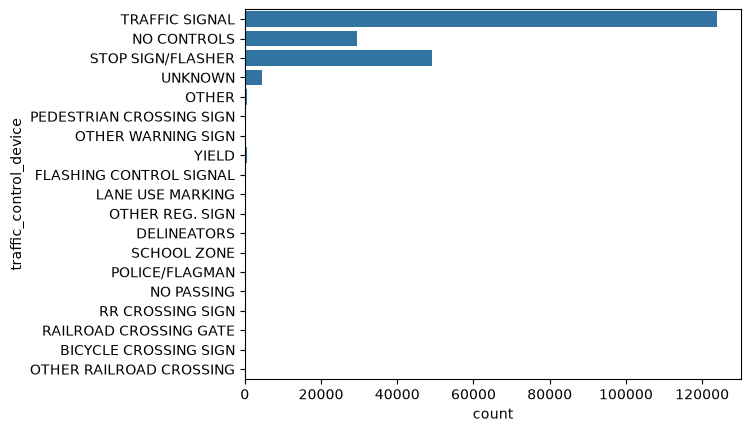

In [12]:
sns.countplot(y=df["traffic_control_device"])

<Axes: xlabel='count', ylabel='lighting_condition'>

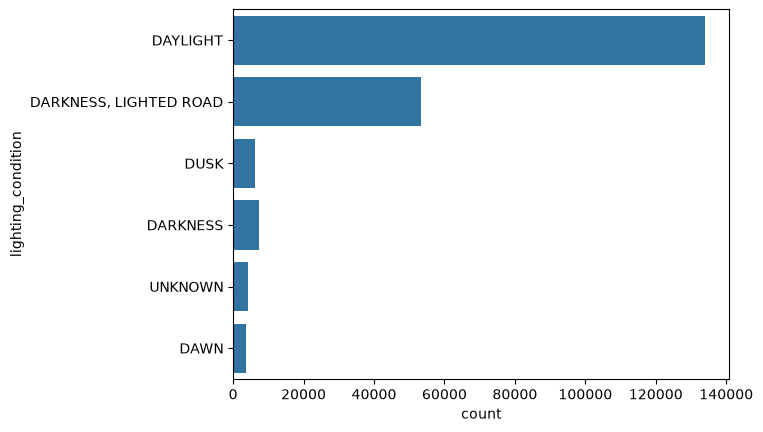

In [13]:
sns.countplot(y=df["lighting_condition"])

<Axes: xlabel='count', ylabel='alignment'>

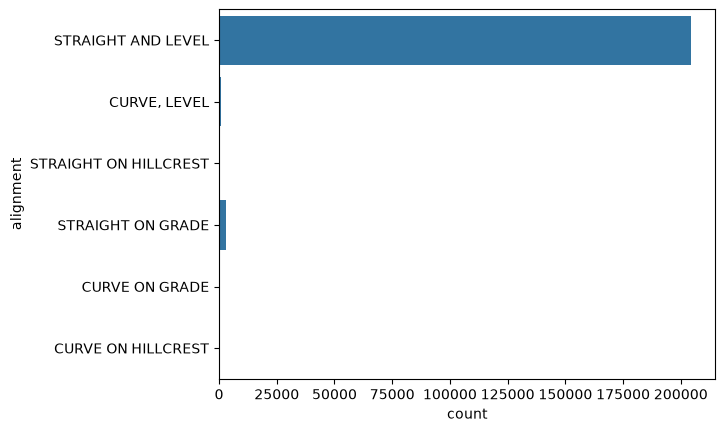

In [14]:
sns.countplot(y=df["alignment"])

<Axes: xlabel='count', ylabel='trafficway_type'>

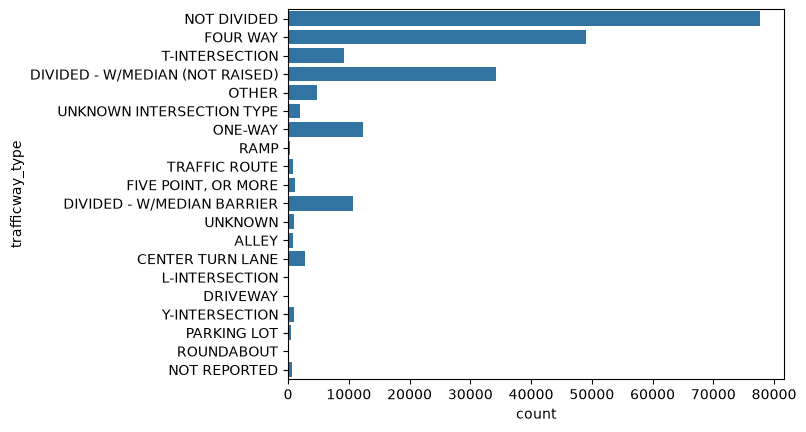

In [15]:
sns.countplot(y=df["trafficway_type"])

<Axes: xlabel='count', ylabel='roadway_surface_cond'>

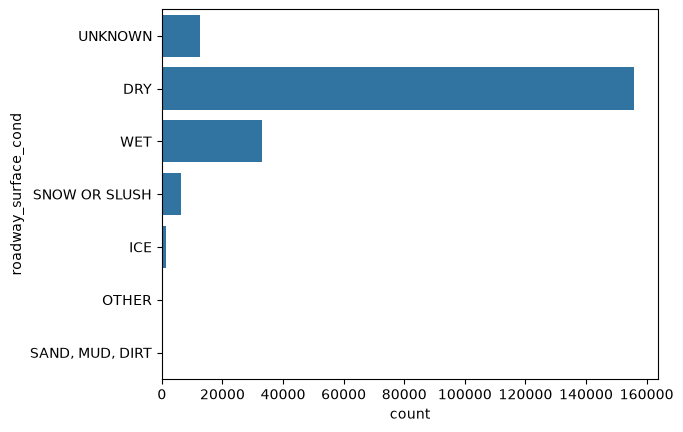

In [16]:
sns.countplot(y=df["roadway_surface_cond"])

<Axes: xlabel='count', ylabel='damage'>

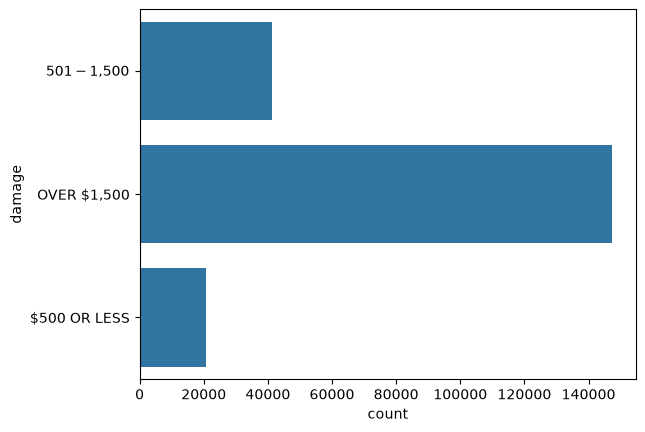

In [17]:
sns.countplot(y=df["damage"])

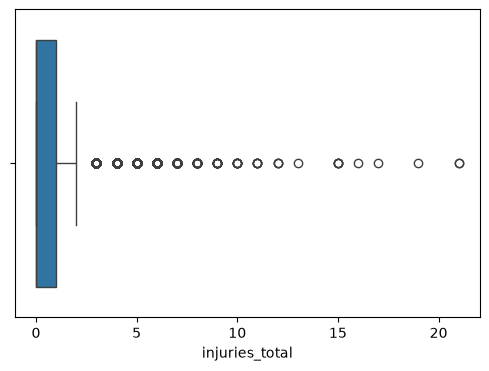

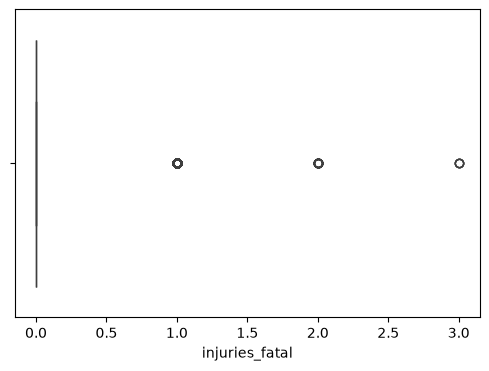

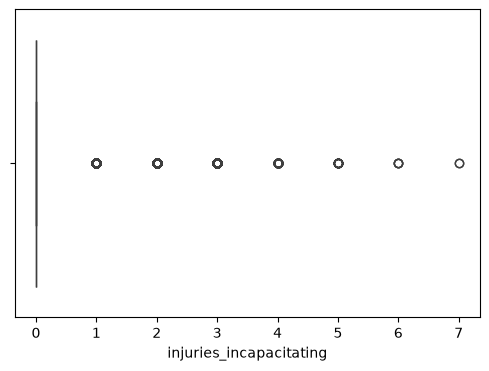

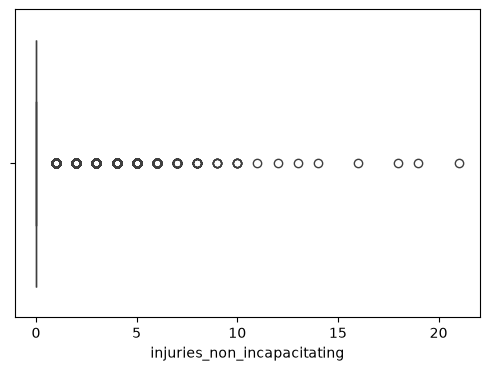

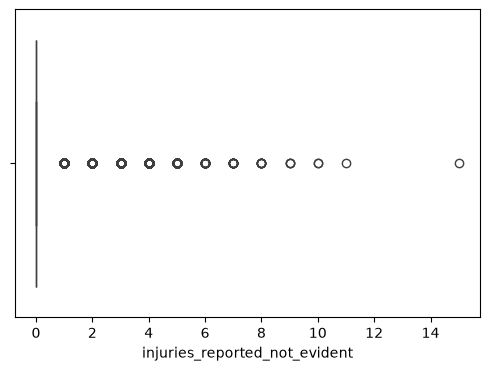

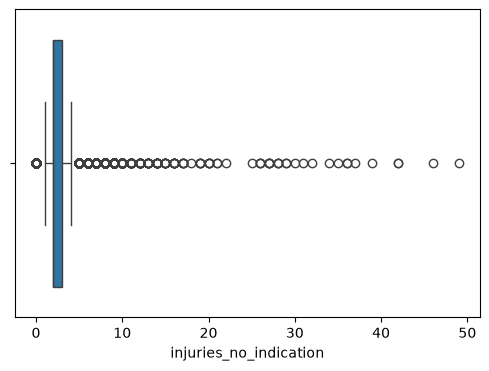

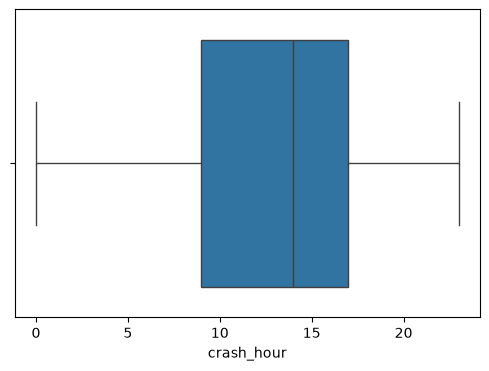

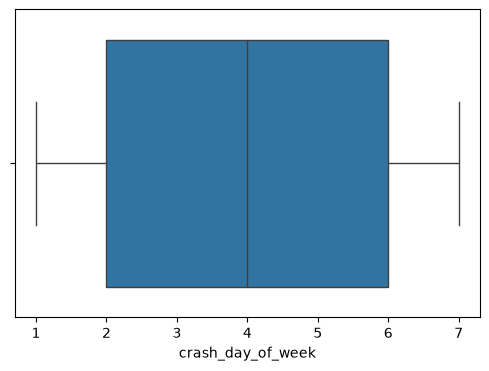

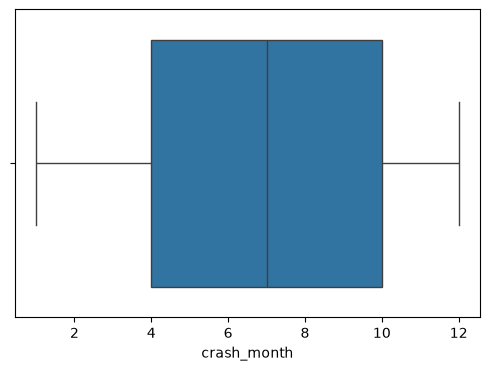

In [18]:
for col in numeric_columns:
    mat.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

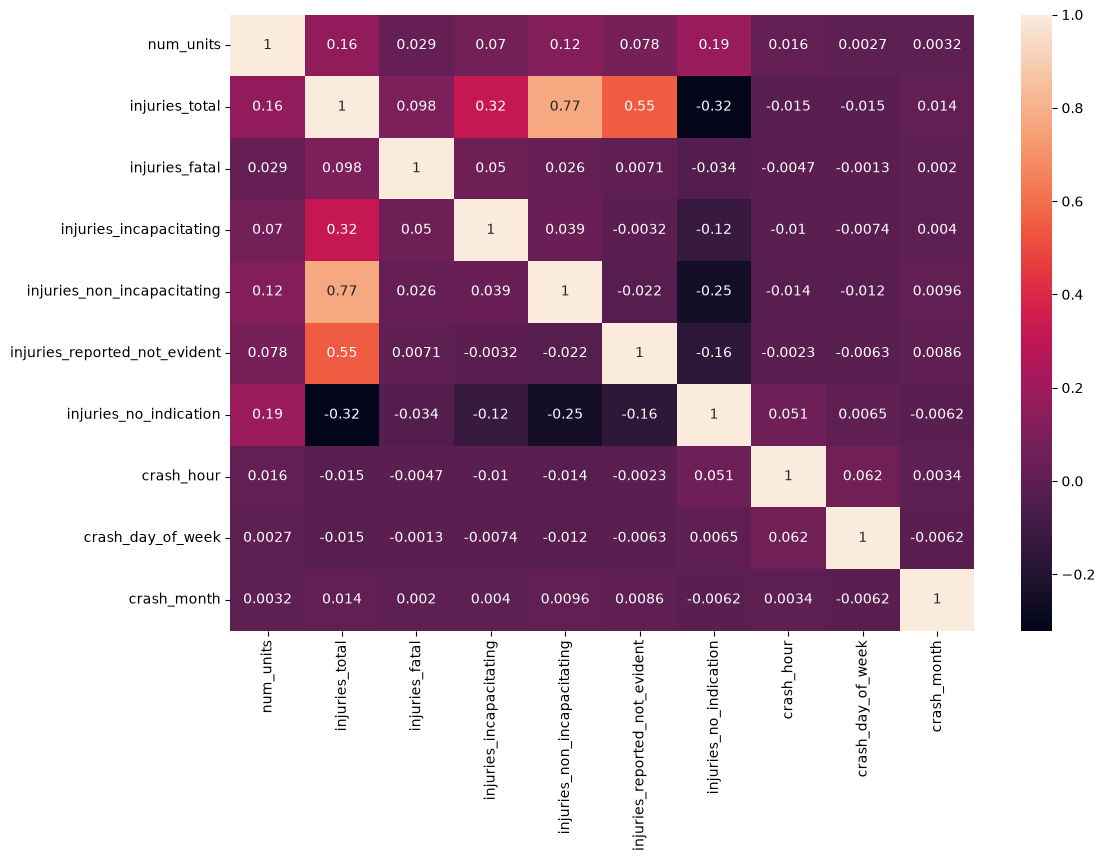

In [19]:
mat.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)

Data Cleaning and Preprocessing

In [20]:
df.shape

(209306, 24)

In [21]:
df.drop_duplicates(inplace=True)
df.head(3)

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12


In [22]:
df.shape

(209275, 24)

That means there is no any duplicate data in this dataset

In [23]:
df.dtypes

crash_date                           str
traffic_control_device               str
weather_condition                    str
lighting_condition                   str
first_crash_type                     str
trafficway_type                      str
alignment                            str
roadway_surface_cond                 str
road_defect                          str
crash_type                           str
intersection_related_i               str
damage                               str
prim_contributory_cause              str
num_units                          int64
most_severe_injury                   str
injuries_total                   float64
injuries_fatal                   float64
injuries_incapacitating          float64
injuries_non_incapacitating      float64
injuries_reported_not_evident    float64
injuries_no_indication           float64
crash_hour                         int64
crash_day_of_week                  int64
crash_month                        int64
dtype: object

In [24]:
df["num_units"].value_counts(), df["road_defect"].value_counts()

(num_units
 2     189337
 3      12249
 1       5123
 4       1908
 5        453
 6        135
 7         34
 8         22
 9          9
 10         4
 11         1
 Name: count, dtype: int64,
 road_defect
 NO DEFECTS           171702
 UNKNOWN               34423
 WORN SURFACE           1000
 OTHER                   912
 RUT, HOLES              741
 SHOULDER DEFECT         358
 DEBRIS ON ROADWAY       139
 Name: count, dtype: int64)

In [25]:
df["traffic_control_device"].value_counts(), df["damage"].value_counts(), df["weather_condition"].value_counts(), df["lighting_condition"].value_counts(), df["first_crash_type"].value_counts(), df["trafficway_type"].value_counts(), df["roadway_surface_cond"].value_counts(), df["alignment"].value_counts(), df["crash_type"].value_counts(), df["intersection_related_i"].value_counts()

(traffic_control_device
 TRAFFIC SIGNAL              123923
 STOP SIGN/FLASHER            49131
 NO CONTROLS                  29507
 UNKNOWN                       4455
 OTHER                          669
 YIELD                          468
 PEDESTRIAN CROSSING SIGN       247
 OTHER REG. SIGN                181
 LANE USE MARKING               153
 FLASHING CONTROL SIGNAL        150
 POLICE/FLAGMAN                 104
 OTHER WARNING SIGN              95
 RAILROAD CROSSING GATE          78
 SCHOOL ZONE                     33
 OTHER RAILROAD CROSSING         23
 RR CROSSING SIGN                18
 DELINEATORS                     17
 NO PASSING                      12
 BICYCLE CROSSING SIGN           11
 Name: count, dtype: int64,
 damage
 OVER $1,500      147294
 $501 - $1,500     41203
 $500 OR LESS      20778
 Name: count, dtype: int64,
 weather_condition
 CLEAR                       164673
 RAIN                         21702
 CLOUDY/OVERCAST               7532
 SNOW                     

label encode (yes=1, no=0)

In [26]:
df["intersection_related_i"]=df["intersection_related_i"].map({"Y":1, "N":0})
df["intersection_related_i"].value_counts()

intersection_related_i
1    199294
0      9981
Name: count, dtype: int64

In [27]:
df["crash_type"]=df["crash_type"].map({"INJURY AND / OR TOW DUE TO CRASH":1, "NO INJURY / DRIVE AWAY":0})
df["crash_type"].value_counts() 

crash_type
0    117356
1     91919
Name: count, dtype: int64

In [28]:
df.rename(columns={"intersection_related_i":"is_intersection_crash", "crash_type":"is_injured"},inplace=True)
df.head(3)

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,is_injured,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,0,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,0,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,0,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12


One Hot Encoding

In [29]:
df=pd.get_dummies(df,columns=["traffic_control_device"], drop_first=True)
df.head(3)

,crash_date,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,is_injured,is_intersection_crash,...,traffic_control_device_OTHER WARNING SIGN,traffic_control_device_PEDESTRIAN CROSSING SIGN,traffic_control_device_POLICE/FLAGMAN,traffic_control_device_RAILROAD CROSSING GATE,traffic_control_device_RR CROSSING SIGN,traffic_control_device_SCHOOL ZONE,traffic_control_device_STOP SIGN/FLASHER,traffic_control_device_TRAFFIC SIGNAL,traffic_control_device_UNKNOWN,traffic_control_device_YIELD
0,07/29/2023 01:00:00 PM,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,0,1,...,False,False,False,False,False,False,False,True,False,False
1,08/13/2023 12:11:00 AM,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,0,1,...,False,False,False,False,False,False,False,True,False,False
2,12/09/2021 10:30:00 AM,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,0,1,...,False,False,False,False,False,False,False,True,False,False


In [30]:
df=pd.get_dummies(df,columns=["weather_condition","lighting_condition"], drop_first=True)
df.head(3)

,crash_date,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,is_injured,is_intersection_crash,damage,prim_contributory_cause,...,weather_condition_RAIN,weather_condition_SEVERE CROSS WIND GATE,weather_condition_SLEET/HAIL,weather_condition_SNOW,weather_condition_UNKNOWN,"lighting_condition_DARKNESS, LIGHTED ROAD",lighting_condition_DAWN,lighting_condition_DAYLIGHT,lighting_condition_DUSK,lighting_condition_UNKNOWN
0,07/29/2023 01:00:00 PM,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,0,1,"$501 - $1,500",UNABLE TO DETERMINE,...,False,False,False,False,False,False,False,True,False,False
1,08/13/2023 12:11:00 AM,TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,0,1,"OVER $1,500",IMPROPER TURNING/NO SIGNAL,...,False,False,False,False,False,True,False,False,False,False
2,12/09/2021 10:30:00 AM,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,0,1,"$501 - $1,500",FOLLOWING TOO CLOSELY,...,False,False,False,False,False,False,False,True,False,False


In [31]:
df["road_defect"].value_counts(), df["prim_contributory_cause"].value_counts()

(road_defect
 NO DEFECTS           171702
 UNKNOWN               34423
 WORN SURFACE           1000
 OTHER                   912
 RUT, HOLES              741
 SHOULDER DEFECT         358
 DEBRIS ON ROADWAY       139
 Name: count, dtype: int64,
 prim_contributory_cause
 UNABLE TO DETERMINE                                                                 58310
 FAILING TO YIELD RIGHT-OF-WAY                                                       42909
 FOLLOWING TOO CLOSELY                                                               19074
 DISREGARDING TRAFFIC SIGNALS                                                        14590
 IMPROPER TURNING/NO SIGNAL                                                          12642
 FAILING TO REDUCE SPEED TO AVOID CRASH                                              10675
 IMPROPER OVERTAKING/PASSING                                                          8302
 DISREGARDING STOP SIGN                                                               6746
 IM

In [32]:
df=pd.get_dummies(df,columns=["first_crash_type","trafficway_type","alignment","roadway_surface_cond","road_defect","damage","prim_contributory_cause"], drop_first=True)
df.head(3)

,crash_date,is_injured,is_intersection_crash,num_units,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,...,prim_contributory_cause_PHYSICAL CONDITION OF DRIVER,prim_contributory_cause_RELATED TO BUS STOP,prim_contributory_cause_ROAD CONSTRUCTION/MAINTENANCE,prim_contributory_cause_ROAD ENGINEERING/SURFACE/MARKING DEFECTS,prim_contributory_cause_TEXTING,prim_contributory_cause_TURNING RIGHT ON RED,prim_contributory_cause_UNABLE TO DETERMINE,prim_contributory_cause_UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),"prim_contributory_cause_VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",prim_contributory_cause_WEATHER
0,07/29/2023 01:00:00 PM,0,1,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,True,False,False,False
1,08/13/2023 12:11:00 AM,0,1,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,12/09/2021 10:30:00 AM,0,1,3,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [33]:
df["crash_date"] = pd.to_datetime(df["crash_date"],format="%m/%d/%Y %I:%M:%S %p")

# Create new columns
df["crash_year"] = df["crash_date"].dt.year.astype(int)
df["crash_month"] = df["crash_date"].dt.month.astype(int)
df["crash_day"] = df["crash_date"].dt.day.astype(int)

In [34]:
df.head(3)

,crash_date,is_injured,is_intersection_crash,num_units,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,...,prim_contributory_cause_ROAD CONSTRUCTION/MAINTENANCE,prim_contributory_cause_ROAD ENGINEERING/SURFACE/MARKING DEFECTS,prim_contributory_cause_TEXTING,prim_contributory_cause_TURNING RIGHT ON RED,prim_contributory_cause_UNABLE TO DETERMINE,prim_contributory_cause_UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),"prim_contributory_cause_VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",prim_contributory_cause_WEATHER,crash_year,crash_day
0,2023-07-29 13:00:00,0,1,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,2023,29
1,2023-08-13 00:11:00,0,1,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,2023,13
2,2021-12-09 10:30:00,0,1,3,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,2021,9


In [35]:
df.drop(columns=["crash_date"], inplace=True)
df.head(3)

,is_injured,is_intersection_crash,num_units,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,...,prim_contributory_cause_ROAD CONSTRUCTION/MAINTENANCE,prim_contributory_cause_ROAD ENGINEERING/SURFACE/MARKING DEFECTS,prim_contributory_cause_TEXTING,prim_contributory_cause_TURNING RIGHT ON RED,prim_contributory_cause_UNABLE TO DETERMINE,prim_contributory_cause_UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),"prim_contributory_cause_VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",prim_contributory_cause_WEATHER,crash_year,crash_day
0,0,1,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,...,False,False,False,False,True,False,False,False,2023,29
1,0,1,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,...,False,False,False,False,False,False,False,False,2023,13
2,0,1,3,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,...,False,False,False,False,False,False,False,False,2021,9


In [36]:
df["most_severe_injury"].value_counts()

most_severe_injury
NO INDICATION OF INJURY     154767
NONINCAPACITATING INJURY     31521
REPORTED, NOT EVIDENT        16073
INCAPACITATING INJURY         6563
FATAL                          351
Name: count, dtype: int64

In [37]:
df["most_severe_injury"]=df["most_severe_injury"].map({"NO INDICATION OF INJURY":0, "NONINCAPACITATING INJURY":1, "REPORTED, NOT EVIDENT":2,"INCAPACITATING INJURY":3, "FATAL":4})
df["most_severe_injury"].value_counts() 

most_severe_injury
0    154767
1     31521
2     16073
3      6563
4       351
Name: count, dtype: int64

In [38]:
df.head(3)

,is_injured,is_intersection_crash,num_units,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,...,prim_contributory_cause_ROAD CONSTRUCTION/MAINTENANCE,prim_contributory_cause_ROAD ENGINEERING/SURFACE/MARKING DEFECTS,prim_contributory_cause_TEXTING,prim_contributory_cause_TURNING RIGHT ON RED,prim_contributory_cause_UNABLE TO DETERMINE,prim_contributory_cause_UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),"prim_contributory_cause_VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",prim_contributory_cause_WEATHER,crash_year,crash_day
0,0,1,2,0,0.0,0.0,0.0,0.0,0.0,3.0,...,False,False,False,False,True,False,False,False,2023,29
1,0,1,2,0,0.0,0.0,0.0,0.0,0.0,2.0,...,False,False,False,False,False,False,False,False,2023,13
2,0,1,3,0,0.0,0.0,0.0,0.0,0.0,3.0,...,False,False,False,False,False,False,False,False,2021,9


In [39]:
df=df.astype(int)

In [40]:
df.head(3)

,is_injured,is_intersection_crash,num_units,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,...,prim_contributory_cause_ROAD CONSTRUCTION/MAINTENANCE,prim_contributory_cause_ROAD ENGINEERING/SURFACE/MARKING DEFECTS,prim_contributory_cause_TEXTING,prim_contributory_cause_TURNING RIGHT ON RED,prim_contributory_cause_UNABLE TO DETERMINE,prim_contributory_cause_UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),"prim_contributory_cause_VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",prim_contributory_cause_WEATHER,crash_year,crash_day
0,0,1,2,0,0,0,0,0,0,3,...,0,0,0,0,1,0,0,0,2023,29
1,0,1,2,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,2023,13
2,0,1,3,0,0,0,0,0,0,3,...,0,0,0,0,0,0,0,0,2021,9


Feature Engineering and Extraction

No need to do bins and labels because it is already categorized labels in most severe injury so I will go for feature scaling in num_units,injuries_no_indication etc

In [41]:
 from sklearn.preprocessing import StandardScaler

In [42]:
cols=["num_units","injuries_total","injuries_fatal","injuries_incapacitating","injuries_non_incapacitating","injuries_reported_not_evident","injuries_no_indication","crash_hour","crash_day_of_week","crash_month","crash_year","crash_day"]
scaler=StandardScaler()
df[cols]=scaler.fit_transform(df[cols])

In [43]:
df.head(5)

,is_injured,is_intersection_crash,num_units,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,...,prim_contributory_cause_ROAD CONSTRUCTION/MAINTENANCE,prim_contributory_cause_ROAD ENGINEERING/SURFACE/MARKING DEFECTS,prim_contributory_cause_TEXTING,prim_contributory_cause_TURNING RIGHT ON RED,prim_contributory_cause_UNABLE TO DETERMINE,prim_contributory_cause_UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),"prim_contributory_cause_VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",prim_contributory_cause_WEATHER,crash_year,crash_day
0,0,1,-0.159835,0,-0.478552,-0.039128,-0.162854,-0.359753,-0.269515,0.609094,...,0,0,0,0,1,0,0,0,1.064451,1.517953
1,0,1,-0.159835,0,-0.478552,-0.039128,-0.162854,-0.359753,-0.269515,-0.196606,...,0,0,0,0,0,0,0,0,1.064451,-0.306505
2,0,1,2.365232,0,-0.478552,-0.039128,-0.162854,-0.359753,-0.269515,0.609094,...,0,0,0,0,0,0,0,0,0.240207,-0.762619
3,1,1,-0.159835,1,5.773651,-0.039128,-0.162854,7.771156,-0.269515,-1.808006,...,0,0,0,0,1,0,0,0,1.064451,-0.762619
4,0,1,-0.159835,0,-0.478552,-0.039128,-0.162854,-0.359753,-0.269515,0.609094,...,0,0,0,0,0,0,0,0,1.064451,0.377667


In [44]:
df.dtypes

is_injured                                                                                      int64
is_intersection_crash                                                                           int64
num_units                                                                                     float64
most_severe_injury                                                                              int64
injuries_total                                                                                float64
                                                                                               ...   
prim_contributory_cause_UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED)      int64
prim_contributory_cause_VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)                    int64
prim_contributory_cause_WEATHER                                                                 int64
crash_year                                                                        

I am going to do crash severity analysis.. so (most_severe_injury) is my output variable.... so I did label encoding for it's string value and i didn't perform standarization for this column.

Pearson Correlation from Scipy Library

In [45]:
from scipy.stats import pearsonr

In [46]:
df.columns

Index(['is_injured', 'is_intersection_crash', 'num_units',
       'most_severe_injury', 'injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication',
       ...
       'prim_contributory_cause_ROAD CONSTRUCTION/MAINTENANCE',
       'prim_contributory_cause_ROAD ENGINEERING/SURFACE/MARKING DEFECTS',
       'prim_contributory_cause_TEXTING',
       'prim_contributory_cause_TURNING RIGHT ON RED',
       'prim_contributory_cause_UNABLE TO DETERMINE',
       'prim_contributory_cause_UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED)',
       'prim_contributory_cause_VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)',
       'prim_contributory_cause_WEATHER', 'crash_year', 'crash_day'],
      dtype='str', length=143)

In [47]:
target = "most_severe_injury"

results = []

for column in df.columns:
    if column != target:
        r, p = pearsonr(df[column], df[target])
        results.append([column, r, p])

corr_df = pd.DataFrame(results, columns=["Feature", "Pearson_r", "P_value"])

# Sort by strongest correlation
corr_df = corr_df.sort_values(by="Pearson_r", ascending=False)
corr_df

,Feature,Pearson_r,P_value
3,injuries_total,0.718250,0.000000e+00
0,is_injured,0.589276,0.000000e+00
5,injuries_incapacitating,0.547274,0.000000e+00
7,injuries_reported_not_evident,0.525819,0.000000e+00
6,injuries_non_incapacitating,0.326313,0.000000e+00
...,...,...,...
119,prim_contributory_cause_FOLLOWING TOO CLOSELY,-0.068773,9.184413e-218
55,first_crash_type_REAR END,-0.086357,0.000000e+00
60,first_crash_type_SIDESWIPE SAME DIRECTION,-0.124975,0.000000e+00
99,"damage_$501 - $1,500",-0.129677,0.000000e+00


This output data didn't displayed it's rows completely.. So, I exported it as .csv file

In [48]:
corr_df.to_csv("correlation_results.csv", index=False)

But, I can also see the complete output data directly

In [49]:
with pd.option_context("display.max_rows", None):
    display(corr_df)
    

,Feature,Pearson_r,P_value
3,injuries_total,0.718250,0.000000e+00
0,is_injured,0.589276,0.000000e+00
5,injuries_incapacitating,0.547274,0.000000e+00
7,injuries_reported_not_evident,0.525819,0.000000e+00
6,injuries_non_incapacitating,0.326313,0.000000e+00
54,first_crash_type_PEDESTRIAN,0.278398,0.000000e+00
4,injuries_fatal,0.181166,0.000000e+00
53,first_crash_type_PEDALCYCLIST,0.142212,0.000000e+00
2,num_units,0.104174,0.000000e+00
106,prim_contributory_cause_DISREGARDING TRAFFIC S...,0.096342,0.000000e+00


Pearson is not ideal for: Binary variables, One-hot encoded variables, Categorical relationships.

Better alternatives
Feature Type
Recommended Test
Numeric → Numeric	Pearson.
Categorical → Categorical	Chi-Square.
Numeric → Categorical Target	ANOVA F-test or Mutual Information.

So I will try from chi-square test

In [50]:
from scipy.stats import chi2_contingency

In [51]:
target = "most_severe_injury"
alpha = 0.05   # Significance level

results = []

for column in df.columns:
    if column != target:
        # Create contingency table
        contingency_table = pd.crosstab(df[column], df[target])

        # Perform Chi-square test
        chi2, p, dof, expected = chi2_contingency(contingency_table)

        # Decision
        decision = "Reject Null Hypothesis (Keep Feature)" if p < alpha else "Accept Null Hypothesis (Remove Feature)"

        results.append([column, chi2, p, dof, decision])

# Create results table
chi_df = pd.DataFrame(
    results,
    columns=["Feature", "Chi2 Statistic", "P-value", "Degrees of Freedom", "Decision"]
)

# Sort by p-value (most significant first)
chi_df = chi_df.sort_values(by="Chi2 Statistic", ascending=False)
chi_df

,Feature,Chi2 Statistic,P-value,Degrees of Freedom,Decision
3,injuries_total,213098.817547,0.000000,72,Reject Null Hypothesis (Keep Feature)
4,injuries_fatal,209275.000000,0.000000,12,Reject Null Hypothesis (Keep Feature)
5,injuries_incapacitating,207805.715850,0.000000,28,Reject Null Hypothesis (Keep Feature)
6,injuries_non_incapacitating,201538.659876,0.000000,72,Reject Null Hypothesis (Keep Feature)
7,injuries_reported_not_evident,179519.747341,0.000000,48,Reject Null Hypothesis (Keep Feature)
...,...,...,...,...,...
134,prim_contributory_cause_TEXTING,2.329327,0.675435,4,Accept Null Hypothesis (Remove Feature)
24,traffic_control_device_RR CROSSING SIGN,2.164852,0.705469,4,Accept Null Hypothesis (Remove Feature)
12,traffic_control_device_DELINEATORS,1.936874,0.747368,4,Accept Null Hypothesis (Remove Feature)
109,prim_contributory_cause_DISTRACTION - FROM OUT...,0.532333,0.970278,4,Accept Null Hypothesis (Remove Feature)


In [52]:
with pd.option_context("display.max_rows", None):
    display(chi_df)

,Feature,Chi2 Statistic,P-value,Degrees of Freedom,Decision
3,injuries_total,213098.817547,0.000000e+00,72,Reject Null Hypothesis (Keep Feature)
4,injuries_fatal,209275.000000,0.000000e+00,12,Reject Null Hypothesis (Keep Feature)
5,injuries_incapacitating,207805.715850,0.000000e+00,28,Reject Null Hypothesis (Keep Feature)
6,injuries_non_incapacitating,201538.659876,0.000000e+00,72,Reject Null Hypothesis (Keep Feature)
7,injuries_reported_not_evident,179519.747341,0.000000e+00,48,Reject Null Hypothesis (Keep Feature)
8,injuries_no_indication,96281.903405,0.000000e+00,152,Reject Null Hypothesis (Keep Feature)
0,is_injured,94071.301734,0.000000e+00,4,Reject Null Hypothesis (Keep Feature)
54,first_crash_type_PEDESTRIAN,22667.056618,0.000000e+00,4,Reject Null Hypothesis (Keep Feature)
53,first_crash_type_PEDALCYCLIST,8060.639880,0.000000e+00,4,Reject Null Hypothesis (Keep Feature)
99,"damage_$501 - $1,500",4717.684736,0.000000e+00,4,Reject Null Hypothesis (Keep Feature)


Now, I want to keep only columns which rejects null hypothesis.. This is called filtering or feature extraction...

In [53]:
# Get the names of significant features
selected_features = chi_df.loc[chi_df["Decision"] == "Reject Null Hypothesis (Keep Feature)","Feature"].tolist()

# Create a new dataset with selected features + target variable
df_selected = df[selected_features + [target]]

df_selected.head()

,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,is_injured,first_crash_type_PEDESTRIAN,first_crash_type_PEDALCYCLIST,"damage_$501 - $1,500",...,prim_contributory_cause_PASSING STOPPED SCHOOL BUS,traffic_control_device_LANE USE MARKING,prim_contributory_cause_OBSTRUCTED CROSSWALKS,prim_contributory_cause_HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE),lighting_condition_DAWN,first_crash_type_REAR TO REAR,traffic_control_device_RAILROAD CROSSING GATE,alignment_STRAIGHT ON GRADE,prim_contributory_cause_MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT,most_severe_injury
0,-0.478552,-0.039128,-0.162854,-0.359753,-0.269515,0.609094,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,-0.478552,-0.039128,-0.162854,-0.359753,-0.269515,-0.196606,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-0.478552,-0.039128,-0.162854,-0.359753,-0.269515,0.609094,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,5.773651,-0.039128,-0.162854,7.771156,-0.269515,-1.808006,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,-0.478552,-0.039128,-0.162854,-0.359753,-0.269515,0.609094,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [54]:
print(df_selected.columns.duplicated().any())

False


In [55]:
df_selected.columns

Index(['injuries_total', 'injuries_fatal', 'injuries_incapacitating',
       'injuries_non_incapacitating', 'injuries_reported_not_evident',
       'injuries_no_indication', 'is_injured', 'first_crash_type_PEDESTRIAN',
       'first_crash_type_PEDALCYCLIST', 'damage_$501 - $1,500',
       ...
       'prim_contributory_cause_PASSING STOPPED SCHOOL BUS',
       'traffic_control_device_LANE USE MARKING',
       'prim_contributory_cause_OBSTRUCTED CROSSWALKS',
       'prim_contributory_cause_HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE)',
       'lighting_condition_DAWN', 'first_crash_type_REAR TO REAR',
       'traffic_control_device_RAILROAD CROSSING GATE',
       'alignment_STRAIGHT ON GRADE',
       'prim_contributory_cause_MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT',
       'most_severe_injury'],
      dtype='str', length=105)

Since, I want to predict Crash Severity, then the factors which creates vehicles crashes are only included as input variables. So, I will remove no. of crashes columns because these columns already revealed the crashes, (these variables already displayed the crashes) which creates data leakage.

In [56]:
df_final=df_selected.drop(columns=["injuries_total", "injuries_fatal", "injuries_incapacitating", "injuries_non_incapacitating", "injuries_reported_not_evident", "injuries_no_indication"])
df_final.head(3)

,is_injured,first_crash_type_PEDESTRIAN,first_crash_type_PEDALCYCLIST,"damage_$501 - $1,500",first_crash_type_SIDESWIPE SAME DIRECTION,num_units,first_crash_type_REAR END,prim_contributory_cause_DISREGARDING TRAFFIC SIGNALS,prim_contributory_cause_FAILING TO YIELD RIGHT-OF-WAY,prim_contributory_cause_FOLLOWING TOO CLOSELY,...,prim_contributory_cause_PASSING STOPPED SCHOOL BUS,traffic_control_device_LANE USE MARKING,prim_contributory_cause_OBSTRUCTED CROSSWALKS,prim_contributory_cause_HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE),lighting_condition_DAWN,first_crash_type_REAR TO REAR,traffic_control_device_RAILROAD CROSSING GATE,alignment_STRAIGHT ON GRADE,prim_contributory_cause_MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT,most_severe_injury
0,0,0,0,1,0,-0.159835,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,-0.159835,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,2.365232,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [57]:
df_final.describe()

,is_injured,first_crash_type_PEDESTRIAN,first_crash_type_PEDALCYCLIST,"damage_$501 - $1,500",first_crash_type_SIDESWIPE SAME DIRECTION,num_units,first_crash_type_REAR END,prim_contributory_cause_DISREGARDING TRAFFIC SIGNALS,prim_contributory_cause_FAILING TO YIELD RIGHT-OF-WAY,prim_contributory_cause_FOLLOWING TOO CLOSELY,...,prim_contributory_cause_PASSING STOPPED SCHOOL BUS,traffic_control_device_LANE USE MARKING,prim_contributory_cause_OBSTRUCTED CROSSWALKS,prim_contributory_cause_HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE),lighting_condition_DAWN,first_crash_type_REAR TO REAR,traffic_control_device_RAILROAD CROSSING GATE,alignment_STRAIGHT ON GRADE,prim_contributory_cause_MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT,most_severe_injury
count,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,2.092750e+05,209275.000000,209275.000000,209275.000000,209275.000000,...,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000
mean,0.439226,0.042982,0.025493,0.196884,0.096113,2.735220e-16,0.200726,0.069717,0.205036,0.091143,...,0.000081,0.000731,0.000229,0.000636,0.017790,0.000234,0.000373,0.014292,0.000033,0.405017
std,0.496294,0.202816,0.157617,0.397645,0.294747,1.000002e+00,0.400545,0.254670,0.403729,0.287813,...,0.009013,0.027029,0.015143,0.025202,0.132188,0.015300,0.019302,0.118693,0.005783,0.776452
min,0.000000,0.000000,0.000000,0.000000,0.000000,-2.684903e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,-1.598355e-01,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,-1.598355e-01,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000,0.000000,-1.598355e-01,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,2.256577e+01,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000


Model splitting

In [58]:
from sklearn.model_selection import train_test_split

In [61]:
X=df_final.drop(["most_severe_injury", "is_injured"], axis=1)
y=df_final["most_severe_injury"]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Model Training (Linear Regression)

In [63]:
from sklearn.linear_model import LinearRegression

In [64]:
model=LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](97,)","[1.06,0.73,0.01,...,0.03,0.05,0.16]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](97,)","['first_crash_type_PEDESTRIAN','first_crash_type_PEDALCYCLIST', 'damage_$501 - $1,500',..., 'traffic_control_device_RAILROAD CROSSING GATE', 'alignment_STRAIGHT ON GRADE', 'prim_contributory_cause_MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.3074
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,97
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(97)


Model Prediction

For Training

In [65]:
y_pred2= model.predict(X_train)
y_pred2

array([-0.09122221,  0.76922   ,  0.36123064, ...,  0.54089758,
        0.45085252,  0.25163352], shape=(167420,))

In [66]:
y_train

146341    0
105262    1
5687      0
17092     0
144978    0
         ..
43483     1
184934    0
50821     0
33107     0
55224     0
Name: most_severe_injury, Length: 167420, dtype: int64

In [67]:
from sklearn.metrics import r2_score

In [68]:
r2_train=r2_score(y_train,y_pred2)
r2_train

0.17020406463503468

For Testing

In [69]:
y_pred= model.predict(X_test)
y_pred

array([0.15187088, 0.32522975, 0.09657757, ..., 0.24262279, 0.10697021,
       0.3593089 ], shape=(41855,))

In [70]:
y_test

49064     0
120674    0
93082     1
33        0
205561    0
         ..
109071    0
65262     0
176182    0
145730    0
75000     0
Name: most_severe_injury, Length: 41855, dtype: int64

Calculate R2

In [71]:
from sklearn.metrics import r2_score

In [72]:
r2=r2_score(y_test,y_pred)
r2

0.16471745245716363

Calculate Adjusted R2

In [73]:
n= X_test.shape[0]
p= X_test.shape[1]
adjusted_r2= 1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.16277712132437971

Here, both trained and tested model performance is bad. So, the condition is underfitting.
Overfitting --> Trained model performance is good but tested model is bad.
Underfitting --> Trained model performance is bad and tested model is also bad.
Perfect --> Trained model performance is good and tested model is also good.

Model is inaccurate because Linear regression should not be used in this case and automatically, r2 should not be used. Linear regression is done when the target (output) variable has continuous values. Here the output variable has categorical values i.e.
NO INDICATION OF INJURY           -> 0
NONINCAPACITATING INJURY          -> 1
REPORTED, NOT EVIDENT             -> 2
INCAPACITATING INJURY             -> 3
FATAL                             -> 4
So, I should apply logistic regression instead of it.

When do we use R²?
Regression                     Classification
Predict traffic delay.	       Predict crash severity.
Predict travel time.	       Predict injury/no injury.
Predict number of crashes.	   Predict fatal/not fatal.
Metrics: MAE, RMSE, R².	       Metrics: Accuracy, Precision, Recall, F1.

Logistic Regression

Before performing model training, I will apply SMOTE because my target variable "most_severe_injury" is highly imbalanced. There are many "No Injury" crashes and very few "Fatal" crashes. Without SMOTE, the model learns mostly from the majority class and tends to ignore the rare but important severe crashes.

Apply SMOTE

In [74]:
from imblearn.over_sampling import SMOTE

In [75]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

Model Training

In [76]:
from sklearn.linear_model import LogisticRegression

max_iter=1000 -->Your dataset has many one-hot encoded features. The default 100 iterations may not converge.
random_state=42 -->Makes results reproducible.

In [77]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_smote, y_train_smote)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

Predict on the Test Data (Use the original test set, not the SMOTE data)

In [78]:
# Predict crash severity classes
y_pred = log_model.predict(X_test)

# Predict class probabilities (optional)
y_prob = log_model.predict_proba(X_test)

y_pred

array([0, 2, 0, ..., 0, 2, 0], shape=(41855,))

In [79]:
y_test

49064     0
120674    0
93082     1
33        0
205561    0
         ..
109071    0
65262     0
176182    0
145730    0
75000     0
Name: most_severe_injury, Length: 41855, dtype: int64

In [80]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.6409986859395532

In [81]:
from sklearn.metrics import classification_report
report= classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
0,0.824577,0.769166,0.795908,30953.000000
1,0.342147,0.408471,0.372379,6304.000000
2,0.083475,0.091757,0.087420,3215.000000
3,0.091019,0.115004,0.101615,1313.000000
4,0.000000,0.000000,0.000000,70.000000
accuracy,0.640999,0.640999,0.640999,0.640999
macro avg,0.268243,0.276880,0.271464,41855.000000
weighted avg,0.670598,0.640999,0.654586,41855.000000


Confusion Matrix

In [82]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[23808,  3425,  2759,   803,   158],
       [ 2738,  2575,   403,   515,    73],
       [ 1806,   901,   295,   189,    24],
       [  499,   584,    71,   151,     8],
       [   22,    41,     6,     1,     0]])

Test for underfitting/underfitting

In [83]:
y_pred3 = log_model.predict(X_train)

# Predict class probabilities (optional)
y_prob3 = log_model.predict_proba(X_train)

y_pred3

array([0, 1, 2, ..., 3, 0, 0], shape=(167420,))

In [84]:
y_train

146341    0
105262    1
5687      0
17092     0
144978    0
         ..
43483     1
184934    0
50821     0
33107     0
55224     0
Name: most_severe_injury, Length: 167420, dtype: int64

In [85]:
accuracy2 = accuracy_score(y_train, y_pred3)
accuracy2

0.6391291363039063

Here, both trained and tested accuracy < 80%, so the model is underfitted.

KNN (K-Nearest Neighbor) Model

Model Training

In [86]:
from sklearn.neighbors import KNeighborsClassifier

In [87]:
knn_model= KNeighborsClassifier(n_neighbors=81)
knn_model.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",81
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](5,)","[0,1,2,3,4]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Model Prediction

In [88]:
y_pred_knn=knn_model.predict(X_test)
y_pred_knn

array([0, 0, 0, ..., 0, 0, 0], shape=(41855,))

In [89]:
y_test

49064     0
120674    0
93082     1
33        0
205561    0
         ..
109071    0
65262     0
176182    0
145730    0
75000     0
Name: most_severe_injury, Length: 41855, dtype: int64

Model Testing

In [90]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [91]:
accuracy_score(y_test, y_pred_knn)

0.7455740054951618

In [92]:
confusion_matrix(y_test, y_pred_knn)

array([[30754,   199,     0,     0,     0],
       [ 5852,   452,     0,     0,     0],
       [ 3063,   152,     0,     0,     0],
       [ 1191,   122,     0,     0,     0],
       [   63,     7,     0,     0,     0]])

In [93]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.75      0.99      0.86     30953
           1       0.48      0.07      0.12      6304
           2       0.00      0.00      0.00      3215
           3       0.00      0.00      0.00      1313
           4       0.00      0.00      0.00        70

    accuracy                           0.75     41855
   macro avg       0.25      0.21      0.20     41855
weighted avg       0.63      0.75      0.65     41855



c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Naive Bayes Model

In [94]:
from sklearn.naive_bayes import GaussianNB

In [95]:
bayes_model= GaussianNB()
bayes_model.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](5,)","[123814., 25217., 12858., 5250., 281.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](5,)","[0.74,0.15,0.08,0.03,0. ]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](5,)","[0,1,2,3,4]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.007e-09
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](97,)","['first_crash_type_PEDESTRIAN','first_crash_type_PEDALCYCLIST', 'damage_$501 - $1,500',..., 'traffic_control_device_RAILROAD CROSSING GATE', 'alignment_STRAIGHT ON GRADE', 'prim_contributory_cause_MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,97
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](5, 97)","[[0.01,0.01,0.23,...,0. ,0.01,0. ], [0.16,0.09,0.09,...,0. ,0.01,0. ], [0.09,0.04,0.12,...,0. ,0.02,0. ], [0.24,0.08,0.08,...,0. ,0.02,0. ], [0.27,0.04,0.05,...,0. ,0.01,0. ]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](5, 97)","[[0.01,0.01,0.18,...,0. ,0.01,0. ], [0.14,0.08,0.08,...,0. ,0.01,0. ], [0.08,0.04,0.1 ,...,0. ,0.02,0. ], [0.18,0.08,0.08,...,0. ,0.02,0. ], [0.2 ,0.04,0.04,...,0. ,0.01,0. ]]"


In [96]:
y_pred_bayes=bayes_model.predict(X_test)
y_pred_bayes

array([4, 4, 2, ..., 0, 2, 4], shape=(41855,))

In [97]:
accuracy_score(y_test, y_pred_bayes)

0.0742802532552861

In [98]:
confusion_matrix(y_test, y_pred_bayes)

array([[ 2693,    10,  3078,  1260, 23912],
       [  125,     9,   243,   370,  5557],
       [   96,     1,   258,   156,  2704],
       [   16,     4,    37,    86,  1170],
       [    0,     0,     1,     6,    63]])

In [99]:
print(classification_report(y_test, y_pred_bayes))

              precision    recall  f1-score   support

           0       0.92      0.09      0.16     30953
           1       0.38      0.00      0.00      6304
           2       0.07      0.08      0.08      3215
           3       0.05      0.07      0.05      1313
           4       0.00      0.90      0.00        70

    accuracy                           0.07     41855
   macro avg       0.28      0.23      0.06     41855
weighted avg       0.74      0.07      0.13     41855



Decision Tree Model

In [100]:
from sklearn import tree

In [101]:
from sklearn.tree import DecisionTreeClassifier

In [102]:
model_DT= DecisionTreeClassifier(random_state=42)
model_DT.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [103]:
y_pred_DT=model_DT.predict(X_test)
y_pred_DT

array([0, 0, 0, ..., 0, 0, 1], shape=(41855,))

In [104]:
accuracy_score(y_test, y_pred_DT)

0.6249671484888305

In [105]:
confusion_matrix(y_test, y_pred_DT)

array([[23922,  3812,  2452,   730,    37],
       [ 3320,  1768,   725,   475,    16],
       [ 2031,   666,   337,   172,     9],
       [  618,   393,   168,   131,     3],
       [   30,    22,    13,     5,     0]])

In [106]:
print(classification_report(y_test, y_pred_DT))

              precision    recall  f1-score   support

           0       0.80      0.77      0.79     30953
           1       0.27      0.28      0.27      6304
           2       0.09      0.10      0.10      3215
           3       0.09      0.10      0.09      1313
           4       0.00      0.00      0.00        70

    accuracy                           0.62     41855
   macro avg       0.25      0.25      0.25     41855
weighted avg       0.64      0.62      0.63     41855



Support Vector Machine(SVM) Model

I used LinearSVC instead SVC because it takes more than an hour to run

In [107]:
from sklearn.svm import LinearSVC

In [108]:
model_svm= LinearSVC(max_iter=2000, class_weight="balanced", random_state=42)
model_svm.fit(X_train_smote,y_train_smote)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",2000
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_

In [109]:
y_pred_svm=model_svm.predict(X_test)
y_pred_svm

array([0, 2, 0, ..., 0, 2, 0], shape=(41855,))

In [110]:
accuracy_score(y_test, y_pred_svm)

0.6671365428264245

In [111]:
confusion_matrix(y_test, y_pred_svm)

array([[25485,  2744,  1666,   754,   304],
       [ 3272,  2069,   254,   597,   112],
       [ 2030,   733,   190,   212,    50],
       [  603,   464,    42,   179,    25],
       [   31,    32,     3,     4,     0]])

In [112]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.81      0.82      0.82     30953
           1       0.34      0.33      0.34      6304
           2       0.09      0.06      0.07      3215
           3       0.10      0.14      0.12      1313
           4       0.00      0.00      0.00        70

    accuracy                           0.67     41855
   macro avg       0.27      0.27      0.27     41855
weighted avg       0.66      0.67      0.66     41855



Here, I can run multiple models at a time using dictionary and get output of all models which will be easy to compare models.

In [113]:
models= {"Logistic Regression":LogisticRegression(), "KNN":KNeighborsClassifier(), "Naive Bayes":GaussianNB(), "Decision Tree":DecisionTreeClassifier(), "SVM":LinearSVC()}

In [114]:
result=[]

In [115]:
from sklearn.metrics import f1_score

In [116]:
for name,model in models.items():
    model.fit(X_train, y_train)
    y_pred_multi=model.predict(X_test)
    acc= accuracy_score(y_test, y_pred_multi)
    f1= f1_score(y_test, y_pred_multi, average="macro")
    result.append({"Model":name, "Accuracy":round(acc,2), "F1 Score":round(f1,2)})

c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [117]:
result

[{'Model': 'Logistic Regression', 'Accuracy': 0.76, 'F1 Score': 0.24},
 {'Model': 'KNN', 'Accuracy': 0.73, 'F1 Score': 0.23},
 {'Model': 'Naive Bayes', 'Accuracy': 0.07, 'F1 Score': 0.06},
 {'Model': 'Decision Tree', 'Accuracy': 0.62, 'F1 Score': 0.25},
 {'Model': 'SVM', 'Accuracy': 0.76, 'F1 Score': 0.24}]

Here, the Logistic Regression has highest accuracy, I will deploy this model for the crash dataset. But, accuracy > 80% for a good model.

In [118]:
import joblib

In [119]:
joblib.dump(models["Logistic Regression"], "logistic_regression.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']